# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

**Objective:** Build a reusable, production-ready machine learning pipeline to predict customer churn.

**Dataset:** Telco Customer Churn (IBM sample dataset, loaded directly from a public CSV)

**Workflow:**
1. Load and explore the data
2. Preprocess features (scaling + encoding) inside a `Pipeline`
3. Train Logistic Regression and Random Forest models
4. Tune hyperparameters with `GridSearchCV`
5. Evaluate and compare models
6. Export the winning pipeline with `joblib` for reuse


## 1. Setup

In [1]:
# Install/upgrade if needed (uncomment on first run in Colab)
# !pip install -q scikit-learn pandas joblib

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score, f1_score
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the Dataset

We use the IBM Telco Customer Churn dataset (7,043 customers, 21 columns), loaded directly
from a public CSV so the notebook runs end-to-end in Colab with no manual upload step.

If you'd rather use your own copy, upload `Telco-Customer-Churn.csv` to the Colab session
and change `DATA_URL` to `"Telco-Customer-Churn.csv"`.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Quick Exploration & Cleaning

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges is read as object because of a few blank strings for new customers (tenure=0).
# Coerce to numeric; the resulting NaNs will be handled by the pipeline's imputer.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after coercion:", df["TotalCharges"].isna().sum())

# customerID is just an identifier, not a predictive feature
df = df.drop(columns=["customerID"])

# Target: Churn (Yes/No) -> 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Churn"].value_counts(normalize=True).rename("proportion")


Missing TotalCharges after coercion: 11


,proportion
Churn,
0,0.73463
1,0.26537


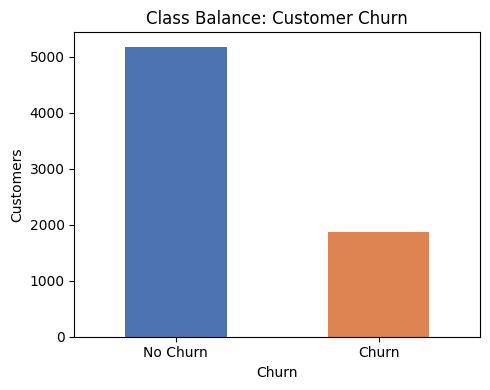

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_xticklabels(["No Churn", "Churn"], rotation=0)
ax.set_ylabel("Customers")
ax.set_title("Class Balance: Customer Churn")
plt.tight_layout()
plt.show()


## 4. Train/Test Split

Split before touching preprocessing so the pipeline's fitted scalers/encoders never see test data
(avoids data leakage).

In [6]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (5634, 19)  Test shape: (1409, 19)


## 5. Preprocessing Pipeline

Numeric and categorical columns get different treatment, combined with `ColumnTransformer`:
- **Numeric** (`tenure`, `MonthlyCharges`, `TotalCharges`): median-impute missing values, then `StandardScaler`
- **Categorical** (everything else): most-frequent-impute, then `OneHotEncoder`

This preprocessing step is itself embedded inside the final model `Pipeline`, so the whole
thing — cleaning, encoding, scaling, and prediction — can be fit and exported as a single object.

In [7]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 6. Model Pipelines

One full `Pipeline` per candidate model: preprocessing + classifier. Keeping preprocessing
inside the pipeline means `GridSearchCV` tunes and cross-validates the whole thing together,
and the exported artifact takes raw-ish input and returns a prediction directly.

In [8]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])


## 7. Hyperparameter Tuning with GridSearchCV

Separate parameter grids for each model, both scored on ROC-AUC (a good fit for a moderately
imbalanced churn target) with 5-fold stratified cross-validation.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_reg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
}

rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4],
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline, log_reg_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)
print("Logistic Regression best CV ROC-AUC:", round(log_reg_grid.best_score_, 4))
print("Logistic Regression best params:", log_reg_grid.best_params_)


Logistic Regression best CV ROC-AUC: 0.8463
Logistic Regression best params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


In [10]:
rf_grid.fit(X_train, y_train)
print("Random Forest best CV ROC-AUC:", round(rf_grid.best_score_, 4))
print("Random Forest best params:", rf_grid.best_params_)


Random Forest best CV ROC-AUC: 0.8461
Random Forest best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}


## 8. Evaluate Both Models on the Held-Out Test Set

In [11]:
def evaluate(name, grid_search, X_test, y_test):
    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}   F1: {f1:.4f}   ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    return {"name": name, "pipeline": best_pipeline, "accuracy": acc, "f1": f1, "roc_auc": auc,
            "y_pred": y_pred, "y_proba": y_proba}

results_log_reg = evaluate("Logistic Regression", log_reg_grid, X_test, y_test)
results_rf = evaluate("Random Forest", rf_grid, X_test, y_test)


--- Logistic Regression ---
Accuracy: 0.8055   F1: 0.6040   ROC-AUC: 0.8411
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest ---
Accuracy: 0.8077   F1: 0.5888   ROC-AUC: 0.8430
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



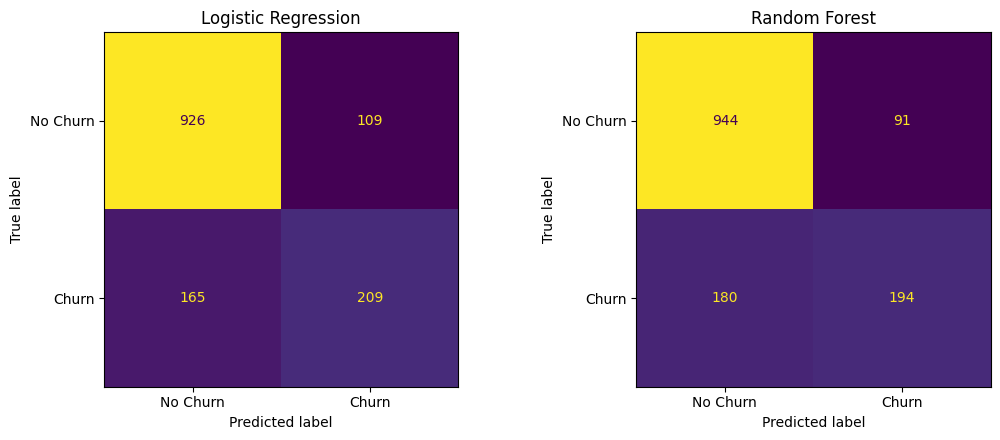

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, res in zip(axes, [results_log_reg, results_rf]):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, colorbar=False)
    ax.set_title(res["name"])
plt.tight_layout()
plt.show()


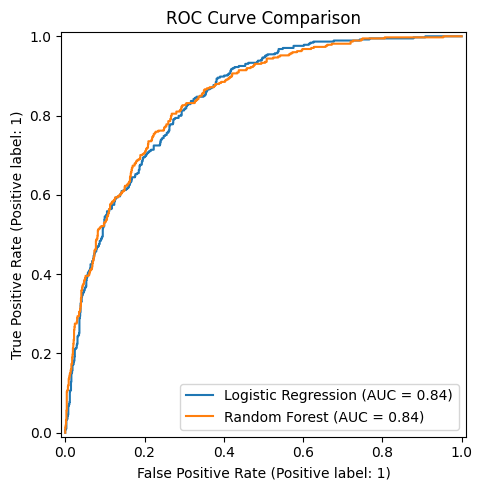

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, results_log_reg["y_proba"], name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, results_rf["y_proba"], name="Random Forest", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()


## 9. Feature Importance (Random Forest)

Since the encoder expands categorical columns into multiple one-hot features, we pull the
generated feature names back out of the fitted `ColumnTransformer` to label the importances.

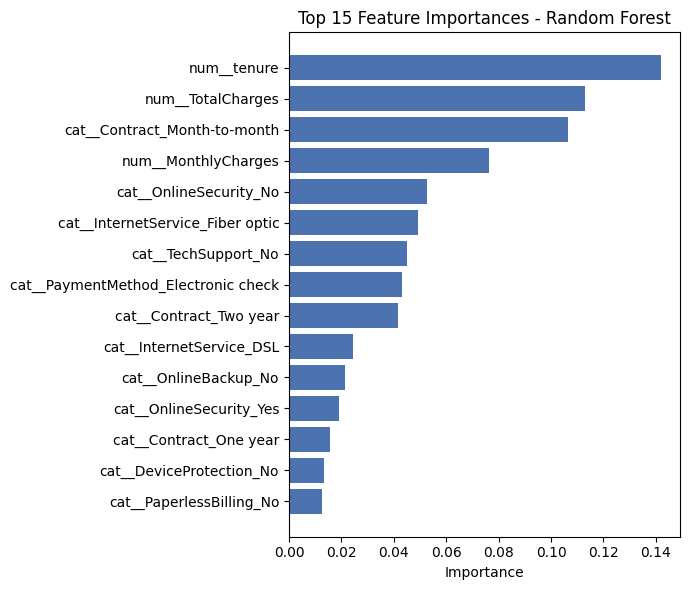

In [14]:
best_rf_pipeline = results_rf["pipeline"]
fitted_preprocessor = best_rf_pipeline.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()

importances = best_rf_pipeline.named_steps["classifier"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_title("Top 15 Feature Importances - Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Select the Best Model and Export with Joblib

Pick whichever pipeline scored higher on test ROC-AUC and export the **entire pipeline**
(preprocessing + tuned classifier) as a single `.joblib` file. Anyone can then load it and call
`.predict()` on raw new customer rows without re-implementing any preprocessing.

In [15]:
candidates = [results_log_reg, results_rf]
best = max(candidates, key=lambda r: r["roc_auc"])
print(f"Best model: {best['name']}  (Test ROC-AUC: {best['roc_auc']:.4f})")

best_pipeline_final = best["pipeline"]

MODEL_PATH = "churn_prediction_pipeline.joblib"
joblib.dump(best_pipeline_final, MODEL_PATH)
print(f"Saved complete pipeline to {MODEL_PATH}")


Best model: Random Forest  (Test ROC-AUC: 0.8430)
Saved complete pipeline to churn_prediction_pipeline.joblib


## 11. Sanity Check: Reload and Predict

Confirms the exported artifact is self-contained and production-ready — it accepts a raw
DataFrame (same raw columns as the original data, minus `customerID`/`Churn`) and returns
predictions with no extra preprocessing code required.

In [16]:
loaded_pipeline = joblib.load(MODEL_PATH)

sample = X_test.iloc[:5]
preds = loaded_pipeline.predict(sample)
probas = loaded_pipeline.predict_proba(sample)[:, 1]

pd.DataFrame({
    "predicted_churn": preds,
    "churn_probability": probas.round(3),
    "actual_churn": y_test.iloc[:5].values,
})


,predicted_churn,churn_probability,actual_churn
0,0,0.014,0
1,1,0.716,0
2,0,0.055,0
3,0,0.336,0
4,0,0.017,0


## 12. Summary

| Model | Test Accuracy | Test F1 | Test ROC-AUC |
|---|---|---|---|
| Logistic Regression | see output above | see output above | see output above |
| Random Forest | see output above | see output above | see output above |

- Preprocessing (imputation, scaling, one-hot encoding) is fully contained inside the exported
  `Pipeline`, so there's no train/test leakage and no separate preprocessing script to maintain.
- `GridSearchCV` tuned both models with 5-fold stratified cross-validation on ROC-AUC.
- The winning pipeline is exported as a single `.joblib` file — load it anywhere with
  `joblib.load("churn_prediction_pipeline.joblib")` and call `.predict()` directly on new data.
